<img src="../logo_UTN.svg" align="right" width="150" /> 

# Teoría De Circuitos 2

# Trabajo Semanal Nº7
#### Federico Borello

### Consigna

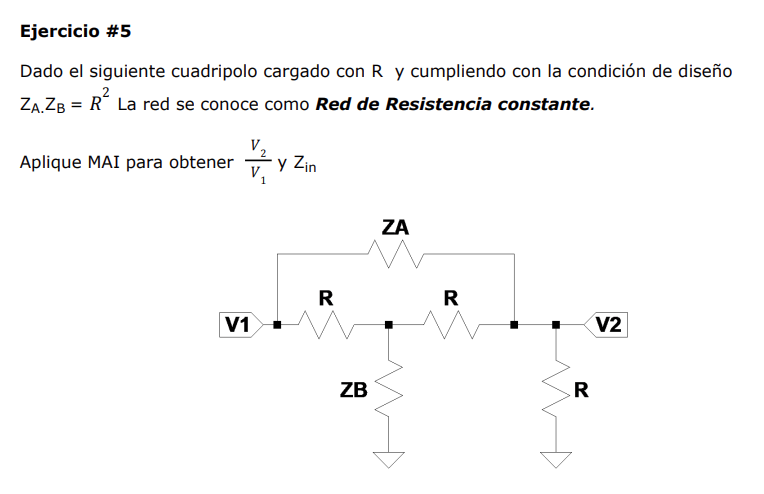

Además:

👉 Obtenga un solo juego de parámetros de cuadripolo $Z$, $Y$ o $ABCD$ y simule en `LTSpice` dicho juego de parámetros de cuadripolo con la directiva `.net`.

👉 Verifique mediante el módulo de simulación simbólica `SymPy` la impedancia de entrada.

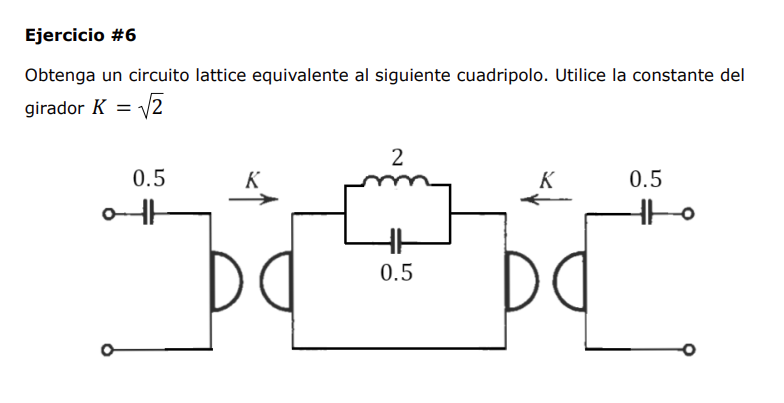

Además:

👉 Simule en `LTSpice` ambos circuitos para verificar la transferencia de tensión $V_2$, tensión medida en el puerto 2 (a derecha) respecto de $V_1$, tensión medida en el puerto 1 (a izquierda).

👉 Verifique mediante el módulo de simulación simbólica `SymPy` los parámetros $T$ de dicha transferencia.


### Procedimiento

Se realiza un análisis a mano de cada circuito. Se detalla a continuación para cada ejercicio.

- Ejercicio1:
  - Se obtiene la MAI.
  - Se calcula la $A=\cfrac{V_2}{V_1}$ y la $Z_{in}$. $Z_{in}$ debe ser igual a $R$ ya que es una **Red de Impedancia Constante** como dice el enunciado.
  - Se obtiene el juego de parámetros de cuadripolo $Z$ del circuito "T-puenteado sin carga" y se lo transforma a los parámetros $ABCD$ para poder multiplicarlos por los parámetros $ABCD$ de la resistencia de carga y obtener los parámetros del circuito "T-puenteado con carga".
  - A partir de los parámetros $ABCD$ del circuito "T-puenteado con carga" se obtiene una expresión para $A=\cfrac{V_2}{V_1}$.
    - Se verifica de manera simbólica utilizando `SymPy`.
  - A partir de los parámetros $Z$ del circuito "T-puenteado sin carga" se obtiene una expresión para $Z_{in}$ teniendo en cuenta una carga conectada.
    - Se verifica de manera simbólica utilizando `SymPy`. Debería ser igual a $Z_{in} = R = \cfrac{1}{G}$.
- Ejercicio2:
    - Se obtiene la matriz $T$ de cada "sub-circuito"/cuadripolo.
    - Se multiplican todas las matrices ya que se encuentran en cascada.
    - Se transforma la matriz $T$ resultante a los parámetros $Z$.
    - Se obtiene un circuito equivalente(Lattice *balanceado*) a partir de los parámetros $Z$.
      - Se verifica utilizando `SymPy`. Y se compara con una simulación en `LTSpice`.

In [1]:
from IPython.display import HTML

file = "./TS7_handwritten.pdf"
html = f"""
<div style="text-align:center;">
    <iframe src="{file}" width="900" height="600"></iframe>
</div>
"""
HTML(html)

In [2]:
# SetUp - Import /utils module
import sys
import os

sys.path.append(os.path.abspath(".."))
import utils.plot as uplt
import utils.synth as usynth

# Import common packages
from IPython.display import display, Markdown
import sympy as sp
import numpy as np

## Ejercicio 1

In [3]:
s = sp.symbols("s")

YA, YB, G = sp.symbols("Y_A Y_B G")

Y_MAI = sp.Matrix(
    [
        [YA + G, 0, -G, -YA],
        [0, YB + G, -YB, -G],
        [-G, -YB, YB + 2 * G, -G],
        [-YA, -G, -G, YA + 2 * G],
    ]
)


def first_order_cofactor(matrix, i, j):
    # i,j en 1-based
    Msub = matrix.minor_submatrix(i - 1, j - 1)  # elimina fila i-1 y columna j-1
    return (-1) ** (i + j) * sp.simplify(Msub.det())


# Asume Y_MAI ya definido en el notebook (4x4)
# Función 1: cofactor de segundo orden "por eliminación" (elimino filas y columnas dadas)
def second_order_cofactor(A, rows_del, cols_del):
    """
    rows_del, cols_del: tuplas/lists con índices 1-based de las filas/cols a eliminar (dos elementos cada una)
    Devuelve (-1)^(sum(rows_del)+sum(cols_del)) * det(submatriz_complementaria)
    """
    n = A.rows
    if len(rows_del) != 2 or len(cols_del) != 2:
        raise ValueError("Se requieren exactamente 2 filas y 2 columnas a eliminar.")
    # convertir a 0-based
    rows_del0 = [r - 1 for r in rows_del]
    cols_del0 = [c - 1 for c in cols_del]
    rows_keep = [i for i in range(n) if i not in rows_del0]
    cols_keep = [j for j in range(n) if j not in cols_del0]
    sub = A.extract(rows_keep, cols_keep)
    display(
        Markdown(f"### Submatriz ({rows_del}, {cols_del})\n$$M = {sp.latex(sub)}$$")
    )
    sign = (-1) ** (sum(rows_del) + sum(cols_del))
    return sp.simplify(sign * sp.simplify(sub.det()))

In [4]:
C_42_12 = second_order_cofactor(Y_MAI, (4, 2), (1, 2))
C_12_12 = second_order_cofactor(Y_MAI, (1, 2), (1, 2))

A = C_42_12 / C_12_12
A_subs = sp.simplify(A.subs(YA * YB, G**2)).simplify()

markdown_msg = f"""
### Cofactores
- $C_{{42,12}} = {sp.latex(C_42_12)}$
- $C_{{12,12}} = {sp.latex(C_12_12)}$
### Transferencia
$$A = \cfrac{{V_2}}{{V_1}} = \cfrac{{C^{{42}}_{{12}}}}{{C^{{12}}_{{12}}}} = {sp.latex(A)}$$
### Teniendo en cuenta que $Y_A \, Y_B = G^2$
$$A = \cfrac{{V_2}}{{V_1}} = \cfrac{{C^{{42}}_{{12}}}}{{C^{{12}}_{{12}}}} = {sp.latex(A_subs)}$$
"""
display(Markdown(markdown_msg))

### Submatriz ((4, 2), (1, 2))
$$M = \left[\begin{matrix}- G & - Y_{A}\\2 G + Y_{B} & - G\end{matrix}\right]$$

### Submatriz ((1, 2), (1, 2))
$$M = \left[\begin{matrix}2 G + Y_{B} & - G\\- G & 2 G + Y_{A}\end{matrix}\right]$$


### Cofactores
- $C_{42,12} = - G^{2} - 2 G Y_{A} - Y_{A} Y_{B}$
- $C_{12,12} = 3 G^{2} + 2 G Y_{A} + 2 G Y_{B} + Y_{A} Y_{B}$
### Transferencia
$$A = \cfrac{V_2}{V_1} = \cfrac{C^{42}_{12}}{C^{12}_{12}} = \frac{- G^{2} - 2 G Y_{A} - Y_{A} Y_{B}}{3 G^{2} + 2 G Y_{A} + 2 G Y_{B} + Y_{A} Y_{B}}$$
### Teniendo en cuenta que $Y_A \, Y_B = G^2$
$$A = \cfrac{V_2}{V_1} = \cfrac{C^{42}_{12}}{C^{12}_{12}} = \frac{- G - Y_{A}}{2 G + Y_{A} + Y_{B}}$$



### Transferencia
- $Y_A = s$ (Un capacitor  $C$=1)
- $Y_B = \frac{1}{s}$ (Una inductancia $L$=1)
- $G = 1$
- $Y_B \, Y_A = G^2$

### Magnitud de la función de transferencia por $Y_{MAI}$
> REVISAR: Hay un error en la fase por el signo menos


$$H(s) = -1 \frac{1s}{1s + 1}$$

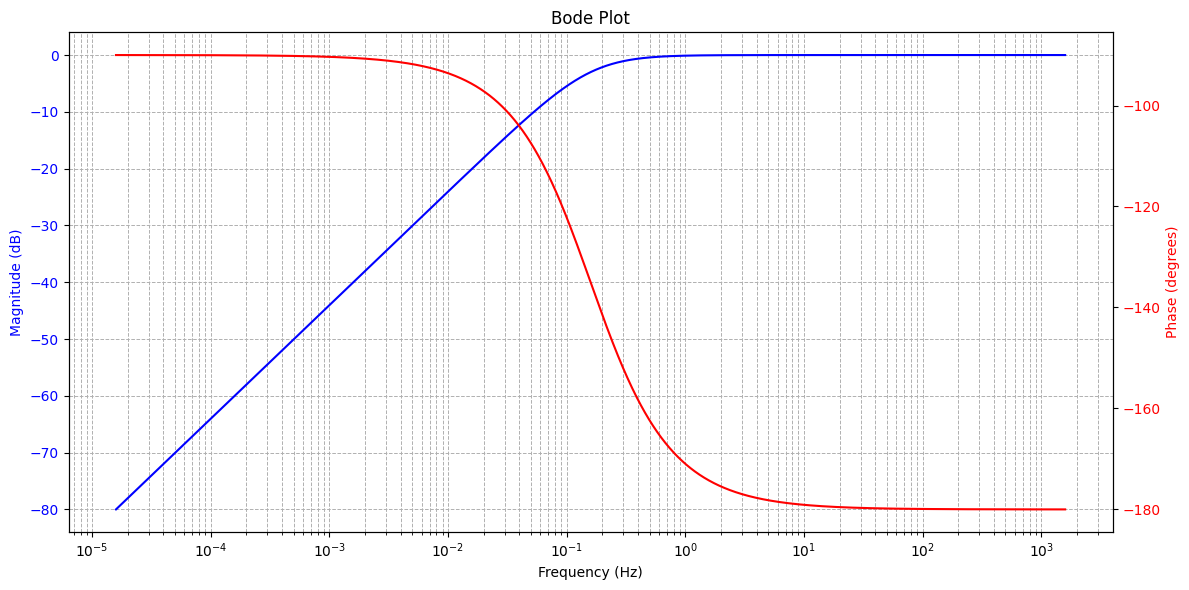

In [5]:
A_subs = A.subs({YA: s, YB: 1 / s, G: 1})
A = sp.simplify(A_subs)

markdown_msg = f"""
### Transferencia
- $Y_A = s$ (Un capacitor  $C$=1)
- $Y_B = \\frac{{1}}{{s}}$ (Una inductancia $L$=1)
- $G = 1$
- $Y_B \, Y_A = G^2$

### Magnitud de la función de transferencia por $Y_{{MAI}}$
> REVISAR: Hay un error en la fase por el signo menos
"""

display(Markdown(markdown_msg))

_ = uplt.plot_tf(A, {}, 1 / (2 * np.pi))

In [6]:
C_12 = first_order_cofactor(Y_MAI, 1, 2)
Z_IN = (C_12_12 / C_12).simplify()
Z_IN_subs = sp.simplify(Z_IN.subs(YA * YB, G**2))

markdown_msg = f"""
### Cofactores
- $C_{{12}} = {sp.latex(C_12)}$
- $C_{{12,12}} = {sp.latex(C_12_12)}$
### Impedancia de Entrada
$$Z_{{\\textbf{{in}}}} = \cfrac{{C^{{12,12}}}}{{C^{{12}}}} = {sp.latex(Z_IN)}$$
### Teniendo en cuenta que $Y_A \, Y_B = G^2$
$$Z_{{\\textbf{{in}}}} = \cfrac{{C^{{12,12}}}}{{C^{{12}}}} = {sp.latex(Z_IN_subs)}$$
"""
display(Markdown(markdown_msg))


### Cofactores
- $C_{12} = - G \left(- G^{2} - 2 G Y_{A} - 2 G Y_{B} - 3 Y_{A} Y_{B}\right)$
- $C_{12,12} = 3 G^{2} + 2 G Y_{A} + 2 G Y_{B} + Y_{A} Y_{B}$
### Impedancia de Entrada
$$Z_{\textbf{in}} = \cfrac{C^{12,12}}{C^{12}} = \frac{3 G^{2} + 2 G Y_{A} + 2 G Y_{B} + Y_{A} Y_{B}}{G \left(G^{2} + 2 G Y_{A} + 2 G Y_{B} + 3 Y_{A} Y_{B}\right)}$$
### Teniendo en cuenta que $Y_A \, Y_B = G^2$
$$Z_{\textbf{in}} = \cfrac{C^{12,12}}{C^{12}} = \frac{1}{G}$$


Por cuadripolos:
- Se obtiene el juego de parámetros de cuadripolo $Z$ del circuito "T-puenteado sin carga" y se lo transforma a los parámetros $ABCD$ para poder multiplicarlos por los parámetros $ABCD$ de la resistencia de carga y obtener los parámetros del circuito "T-puenteado con carga".
- A partir de los parámetros $ABCD$ del circuito "T-puenteado con carga" se obtiene una expresión para $A=\cfrac{V_2}{V_1}$.
    - Se verifica de manera simbólica utilizando `SymPy`.
- A partir de los parámetros $Z$ del circuito "T-puenteado sin carga" se obtiene una expresión para $Z_{in}$ teniendo en cuenta una carga conectada.
    - Se verifica de manera simbólica utilizando `SymPy`. Debería ser igual a $Z_{in} = R = \cfrac{1}{G}$.

In [7]:
def Z_to_ABCD(Z):
    """
    Transforma los parámetros de impedancia Z a parámetros ABCD.
    """
    Z11, _Z12, Z21, Z22 = Z[0, 0], Z[0, 1], Z[1, 0], Z[1, 1]
    delta_Z = Z.det()
    A = Z11 / Z21
    B = delta_Z / Z21
    C = 1 / Z21
    D = Z22 / Z21
    return sp.Matrix([[A, B], [C, D]])


# T-puenteado sin carga
ZA, ZB, R = sp.symbols("Z_A Z_B R")
YA, YB, G = sp.symbols("Y_A Y_B G")
Z_params = sp.Matrix(
    [
        [R * (ZA + R) / (2 * R + ZA) + ZB, ZB + R**2 / (ZA + 2 * R)],
        [ZB + R**2 / (ZA + 2 * R), R * (ZA + R) / (2 * R + ZA) + ZB],
    ]
)
T_params = Z_to_ABCD(Z_params)

T_load = sp.Matrix([[1, 0], [1 / R, 1]])
T_total = T_params * T_load

A = T_total[0, 0]
A = 1 / A
A = A.subs({ZA: 1 / YA, ZB: 1 / YB, R: 1 / G}).simplify()
A = A.expand().subs(YA * YB, G**2).simplify()

markdown_msg = f"""
### Parámetros $Z$ - "Tee-puenteado sin carga"
$$Z = {sp.latex(Z_params)} \Rightarrow T = {sp.latex(T_params)}$$
### Parámetros $T$ - "Tee-puenteado con carga"
$$T_{{\\textbf{{total}}}} = T_{{\\textbf{{tee sin carga}}}} \\, T_{{\\textbf{{load}}}} = {sp.latex(T_params)} \\, {sp.latex(T_load)} = {sp.latex(T_total)}$$
### Transferencia $\\frac{{V_2}}{{V_1}}$
$$1/A = \\cfrac{{V_2}}{{V_1}} = T_{{\\textbf{{total}}_{{0,0}}}} = {sp.latex(A)}$$
"""

display(Markdown(markdown_msg))


### Parámetros $Z$ - "Tee-puenteado sin carga"
$$Z = \left[\begin{matrix}\frac{R \left(R + Z_{A}\right)}{2 R + Z_{A}} + Z_{B} & \frac{R^{2}}{2 R + Z_{A}} + Z_{B}\\\frac{R^{2}}{2 R + Z_{A}} + Z_{B} & \frac{R \left(R + Z_{A}\right)}{2 R + Z_{A}} + Z_{B}\end{matrix}\right] \Rightarrow T = \left[\begin{matrix}\frac{\frac{R \left(R + Z_{A}\right)}{2 R + Z_{A}} + Z_{B}}{\frac{R^{2}}{2 R + Z_{A}} + Z_{B}} & \frac{R^{2} Z_{A} + 2 R Z_{A} Z_{B}}{\left(2 R + Z_{A}\right) \left(\frac{R^{2}}{2 R + Z_{A}} + Z_{B}\right)}\\\frac{1}{\frac{R^{2}}{2 R + Z_{A}} + Z_{B}} & \frac{\frac{R \left(R + Z_{A}\right)}{2 R + Z_{A}} + Z_{B}}{\frac{R^{2}}{2 R + Z_{A}} + Z_{B}}\end{matrix}\right]$$
### Parámetros $T$ - "Tee-puenteado con carga"
$$T_{\textbf{total}} = T_{\textbf{tee sin carga}} \, T_{\textbf{load}} = \left[\begin{matrix}\frac{\frac{R \left(R + Z_{A}\right)}{2 R + Z_{A}} + Z_{B}}{\frac{R^{2}}{2 R + Z_{A}} + Z_{B}} & \frac{R^{2} Z_{A} + 2 R Z_{A} Z_{B}}{\left(2 R + Z_{A}\right) \left(\frac{R^{2}}{2 R + Z_{A}} + Z_{B}\right)}\\\frac{1}{\frac{R^{2}}{2 R + Z_{A}} + Z_{B}} & \frac{\frac{R \left(R + Z_{A}\right)}{2 R + Z_{A}} + Z_{B}}{\frac{R^{2}}{2 R + Z_{A}} + Z_{B}}\end{matrix}\right] \, \left[\begin{matrix}1 & 0\\\frac{1}{R} & 1\end{matrix}\right] = \left[\begin{matrix}\frac{\frac{R \left(R + Z_{A}\right)}{2 R + Z_{A}} + Z_{B}}{\frac{R^{2}}{2 R + Z_{A}} + Z_{B}} + \frac{R^{2} Z_{A} + 2 R Z_{A} Z_{B}}{R \left(2 R + Z_{A}\right) \left(\frac{R^{2}}{2 R + Z_{A}} + Z_{B}\right)} & \frac{R^{2} Z_{A} + 2 R Z_{A} Z_{B}}{\left(2 R + Z_{A}\right) \left(\frac{R^{2}}{2 R + Z_{A}} + Z_{B}\right)}\\\frac{1}{\frac{R^{2}}{2 R + Z_{A}} + Z_{B}} + \frac{\frac{R \left(R + Z_{A}\right)}{2 R + Z_{A}} + Z_{B}}{R \left(\frac{R^{2}}{2 R + Z_{A}} + Z_{B}\right)} & \frac{\frac{R \left(R + Z_{A}\right)}{2 R + Z_{A}} + Z_{B}}{\frac{R^{2}}{2 R + Z_{A}} + Z_{B}}\end{matrix}\right]$$
### Transferencia $\frac{V_2}{V_1}$
$$1/A = \cfrac{V_2}{V_1} = T_{\textbf{total}_{0,0}} = \frac{G + Y_{A}}{2 G + Y_{A} + Y_{B}}$$



### Transferencia
- $Y_A = s$ (Un capacitor  $C$=1)
- $Y_B = \frac{1}{s}$ (Una inductancia $L$=1)
- $G = 1$
- $Y_B \, Y_A = G^2$

### Magnitud de la función de transferencia por Cuadripolos


$$H(s) = 1 \frac{1s}{1s + 1}$$

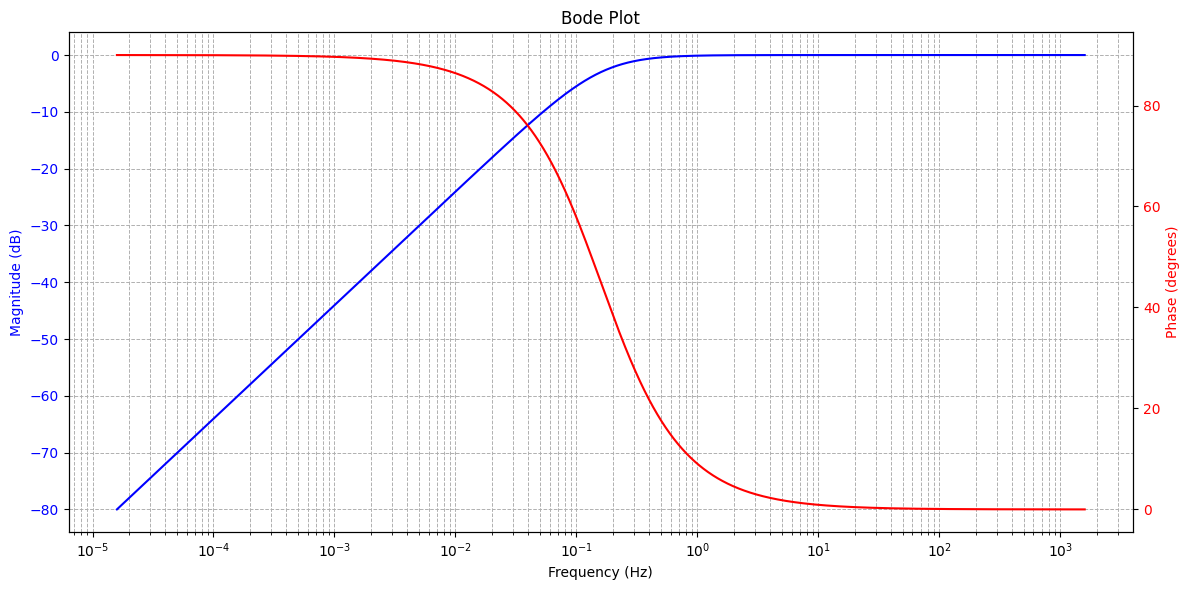

In [8]:
A = A.subs({YA: s, YB: 1 / s, G: 1})
A = sp.simplify(A)

markdown_msg = f"""
### Transferencia
- $Y_A = s$ (Un capacitor  $C$=1)
- $Y_B = \\frac{{1}}{{s}}$ (Una inductancia $L$=1)
- $G = 1$
- $Y_B \, Y_A = G^2$

### Magnitud de la función de transferencia por Cuadripolos
"""

display(Markdown(markdown_msg))

_ = uplt.plot_tf(A, {}, 1 / (2 * np.pi))

In [9]:
# Cuadripolo Cargado
V1, V2, I1, I2 = sp.symbols("V_1 V_2 I_1 I_2")
Z11, Z12, Z21, Z22, ZL = sp.symbols("Z_{11} Z_{12} Z_{21} Z_{22} Z_L")

eq1 = sp.Eq(V1, Z11 * I1 + Z12 * I2)
eq2 = sp.Eq(V2, Z21 * I1 + Z22 * I2)
# Condición de carga: V2 = ZL * -I2
eq_load = sp.Eq(V2, ZL * -I2)

sol = sp.solve([eq2, eq_load], [V2, I2], dict=True)
sol = sol[0]
I2_expr = sp.simplify(sol[I2])
V2_expr = sp.simplify(sol[V2])

V1_expr = sp.simplify(Z11 * I1 + Z12 * I2_expr)
Zin_expr = sp.simplify(sp.factor(V1_expr / I1))

Zin_expr = Zin_expr.subs({Z22: Z11, Z21: Z12})
Zin = Zin_expr.subs({Z11: Z_params[0, 0], Z12: Z_params[0, 1], ZL: R}).simplify()
Zin_final = Zin.subs(ZA * ZB, R**2)
Zin_final
markdown_msg = f"""
### Cuadripolo Z cargado
A partir de las ecuaciones:
- ${sp.latex(eq1)}$
- ${sp.latex(eq2)}$
- ${sp.latex(eq_load)}$

Se obtiene la expresión de la impedancia de entrada:
$$Z_{{\\textbf{{in}}}} = \\frac{{V_1}}{{I_1}} = {sp.latex(Zin_expr)}$$
### Reemplazando $Z_{{11}} = Z_{{22}}$ y $Z_{{21}} = Z_{{12}}$
$$Z_{{\\textbf{{in}}}} = {sp.latex(Zin)}$$
### Teniendo en cuenta que $Z_A \, Z_B = R^2$
$$Z_{{\\textbf{{in}}}} = {sp.latex(Zin_final)}$$
"""

display(Markdown(markdown_msg))


### Cuadripolo Z cargado
A partir de las ecuaciones:
- $V_{1} = I_{1} Z_{11} + I_{2} Z_{12}$
- $V_{2} = I_{1} Z_{21} + I_{2} Z_{22}$
- $V_{2} = - I_{2} Z_{L}$

Se obtiene la expresión de la impedancia de entrada:
$$Z_{\textbf{in}} = \frac{V_1}{I_1} = \frac{Z_{L} Z_{11} + Z_{11}^{2} - Z_{12}^{2}}{Z_{L} + Z_{11}}$$
### Reemplazando $Z_{11} = Z_{22}$ y $Z_{21} = Z_{12}$
$$Z_{\textbf{in}} = \frac{R \left(R^{2} + 2 R Z_{A} + 2 R Z_{B} + 3 Z_{A} Z_{B}\right)}{3 R^{2} + 2 R Z_{A} + 2 R Z_{B} + Z_{A} Z_{B}}$$
### Teniendo en cuenta que $Z_A \, Z_B = R^2$
$$Z_{\textbf{in}} = R$$


### Simulación con LT Spice

Circuito Completo:

<div align=center>

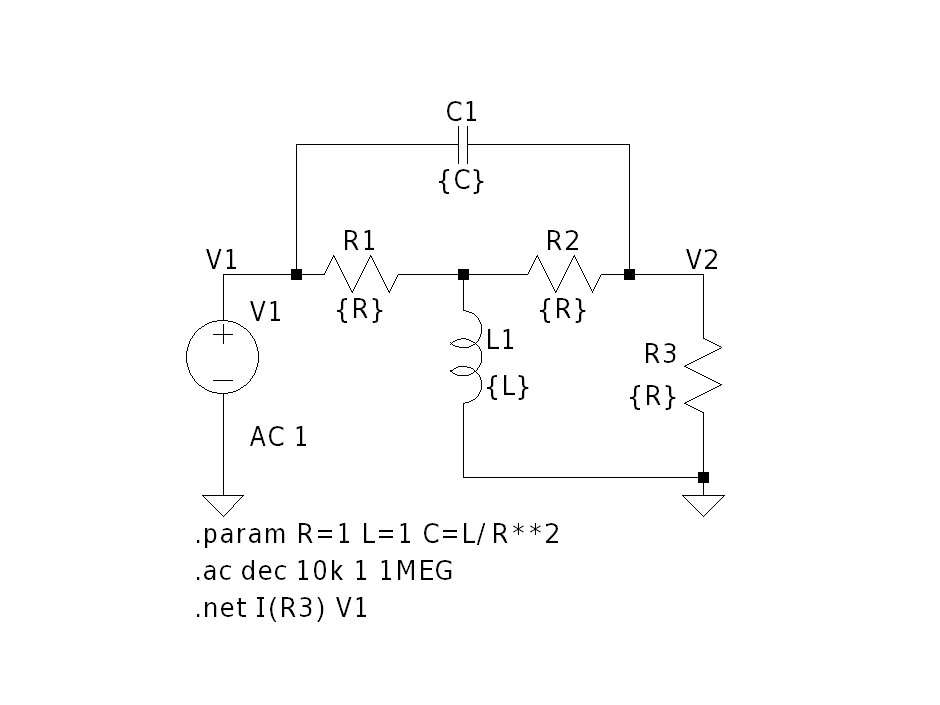

</div>

<a href="./TS7_1.asc" download="TS7_1.asc">Descargar TS7_1.asc</a>

<a href="./TS7_1.plt" download="TS7_1.plt">Descargar TS7_1.plt</a>

$Z_{\text{in}}$ y parámetros $ABCD$:

<div align=center>

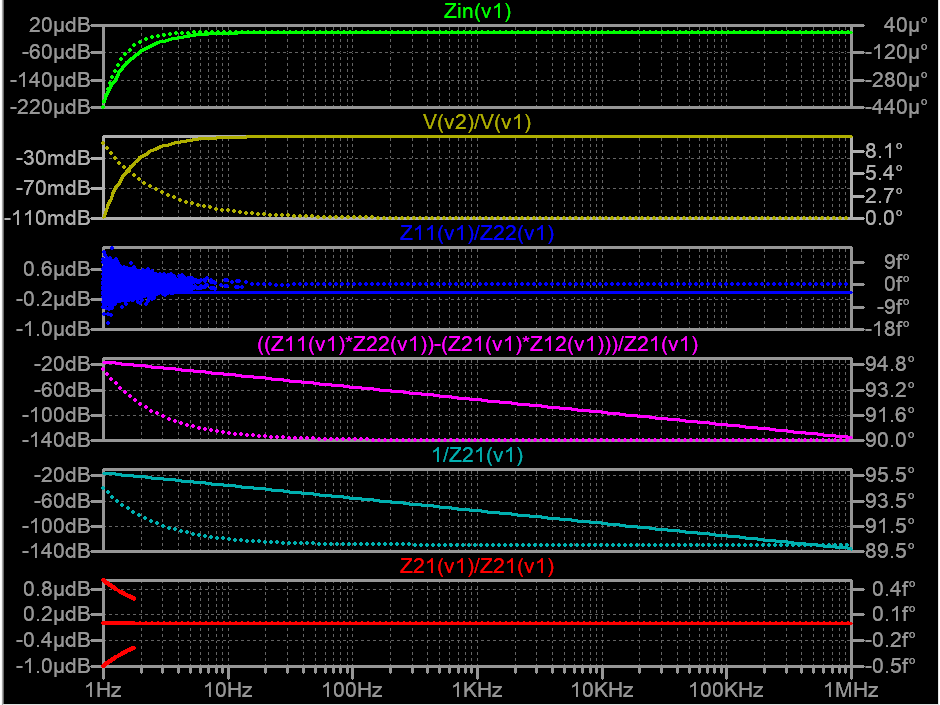

</div>

### Conclusiones/Comentarios

Al analizar la MAI se obtiene una función de transferencia que relaciona las tensiones de entrada y salida en el circuito. Esta función de transferencia debería coincidir con la obtenida a partir de los parámetros T del circuito que se han derivado previamente, pero hay una discrepancia con el signo, lo que sugiere que podría haber un error en la formulación de los parámetros o en la interpretación de los resultados. El signo termina afectando a la fase, la cual en `LTSpice` se puede observar que es de 0° y no de 180° como se espera de una transferencia negativa.

Por otra parte, la impedancia de entrada obtenida con la MAI concuerda con la obtenida a partir de los parámetros Z del circuito, reforzando la validez del resultado.


## Ejercicio 2

In [10]:
T1 = sp.Matrix([[1, 2 / s], [0, 1]])
T2 = sp.Matrix([[0, -2], [-1 / 2, 0]])
T3 = sp.Matrix([[1, 2 * s / (s**2 + 1)], [0, 1]])
T4 = sp.Matrix([[0, -2], [-1 / 2, 0]])
T5 = sp.Matrix([[1, 2 / s], [0, 1]])

Ttotal = T1 * T2 * T3 * T4 * T5
Ttotal = sp.simplify(Ttotal)
markdown_msg = f"""
### Cuadripolo $T_{{\\textbf{{total}}}}$
$$T_{{\\textbf{{total}}}} = {sp.latex(Ttotal)} = {sp.latex(T1)}\, {sp.latex(T2)}\, {sp.latex(T3)}\, {sp.latex(T4)}\, {sp.latex(T5)}$$
"""

display(Markdown(markdown_msg))


### Cuadripolo $T_{\textbf{total}}$
$$T_{\textbf{total}} = \left[\begin{matrix}\frac{1.0 s^{2} + 2.0}{s^{2} + 1} & \frac{4.0 s^{2} + 6.0}{s \left(s^{2} + 1\right)}\\\frac{0.5 s}{s^{2} + 1} & \frac{1.0 s^{2} + 2.0}{s^{2} + 1}\end{matrix}\right] = \left[\begin{matrix}1 & \frac{2}{s}\\0 & 1\end{matrix}\right]\, \left[\begin{matrix}0 & -2\\-0.5 & 0\end{matrix}\right]\, \left[\begin{matrix}1 & \frac{2 s}{s^{2} + 1}\\0 & 1\end{matrix}\right]\, \left[\begin{matrix}0 & -2\\-0.5 & 0\end{matrix}\right]\, \left[\begin{matrix}1 & \frac{2}{s}\\0 & 1\end{matrix}\right]$$


$$H(s) = 1 \frac{1s^2 + 1}{1s^2 + 2}$$

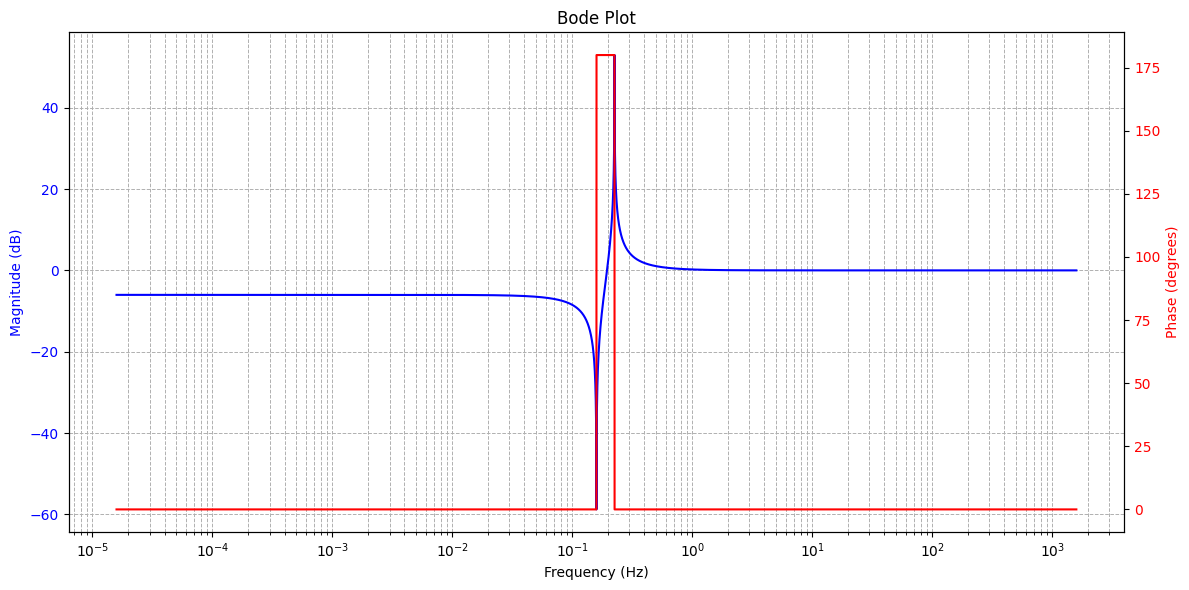

In [11]:
A = 1 / Ttotal[0, 0]
_ = uplt.plot_tf(A, {}, 1/(2*np.pi))

In [12]:
def T_to_Z(T):
    A, B, C, D = T[0, 0], T[0, 1], T[1, 0], T[1, 1]
    Z11 = A / C
    Z12 = (A * D - B * C) / C
    Z21 = 1 / C
    Z22 = D / C
    return sp.simplify(sp.Matrix([[Z11, Z12], [Z21, Z22]]))


Ztotal = T_to_Z(Ttotal).simplify()

markdown_msg = f"""
### Cuadripolo $Z_{{\\textbf{{total}}}}$
$$Z_{{\\textbf{{total}}}} = {sp.latex(Ztotal)}$$
"""

display(Markdown(markdown_msg))


### Cuadripolo $Z_{\textbf{total}}$
$$Z_{\textbf{total}} = \left[\begin{matrix}2.0 s + \frac{4.0}{s} & 2.0 s + \frac{2.0}{s}\\2.0 s + \frac{2.0}{s} & 2.0 s + \frac{4.0}{s}\end{matrix}\right]$$


In [13]:
ZA, ZB = sp.symbols("Z_A, Z_B")

# Ecuaciones teniendo en cuenta los parámetros del Lattice Simétrico
eq1 = sp.Eq((ZB + ZA) / 2, Ztotal[0, 0])
eq2 = sp.Eq((ZB - ZA) / 2, Ztotal[0, 1])

solution = sp.solve((eq1, eq2), (ZA, ZB))
markdown_msg = f"""
### Circuito Lattice Equivalente
$$Z_{{\\textbf{{A}}}} = {sp.latex(solution[ZA])}$$
$$Z_{{\\textbf{{B}}}} = {sp.latex(solution[ZB])}$$
"""

display(Markdown(markdown_msg))


### Circuito Lattice Equivalente
$$Z_{\textbf{A}} = \frac{2.0}{s}$$
$$Z_{\textbf{B}} = \frac{4.0 s^{2} + 6.0}{s}$$


### Simulación con LT Spice

Se realiza un archivo `.net` con las interconexiones pertinentes para simular un Cuadripolo de parámetros $Z$ (`two-port` network). Luego se hace un subcircuito para encapsular el comportamiento del cuadripolo como GIC, finalizando con la creación del símbolo en un `.asy` para poder utilizarlo en cualquier `.asc`.


`gic.net`:

```
* === Two–port por Z con estabilización ===
.subckt TWO_PORT_Z p1 n1 p2 n2 params: Z11=0 Z12=0 Z21=0 Z22=0 Rser=1u Rleak=1e12
* Serie mínima en cada puerto (rompe lazos de V)
Rser1 p1 p1s {Rser}
Rser2 p2 p2s {Rser}

* Sensores de corriente
Vsen1 p1s a 0
Vsen2 p2s b 0

* Leaks para dar camino DC (no afectan AC por ser enormes)
Rleak1 a 0 {Rleak}
Rleak2 b 0 {Rleak}

* V(port) = Z * I
Bport1 a n1 V = { Z11*I(Vsen1) + Z12*I(Vsen2) }
Bport2 b n2 V = { Z21*I(Vsen1) + Z22*I(Vsen2) }
.ends TWO_PORT_Z

* === GIC ideal (gyrator) ===
.subckt GIC_IDEAL p1 n1 p2 n2 params: r=1 Rser=1u Rleak=1e12
Xz p1 n1 p2 n2 TWO_PORT_Z Z11=0 Z22=0 Z12={r} Z21={-r} Rser={Rser} Rleak={Rleak}
.ends GIC_IDEAL

```

Comparación del circuito con GICs y Circuito con Lattice equivalente:

<div align=center>

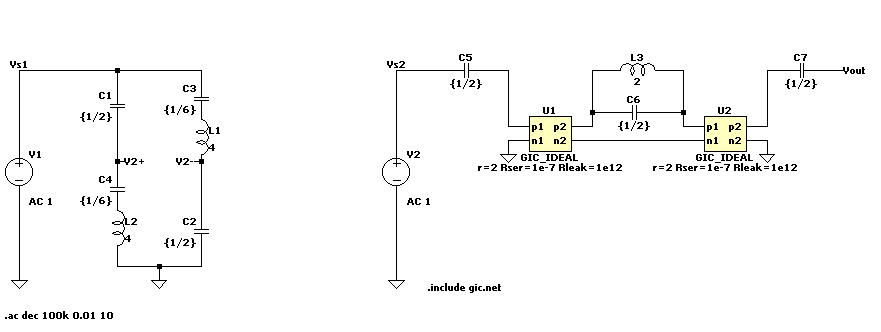

</div>

<a href="./TS7_2.asc" download="TS7_2.asc">Descargar TS7_2.asc</a>

<a href="./TS7_2.plt" download="TS7_2.plt">Descargar TS7_2.plt</a>

Módulo y Fase. Verde es el circuito con GICs, Azul el circuito con Lattice y el último gráfico son ambos en la misma figura:

<div align=center>

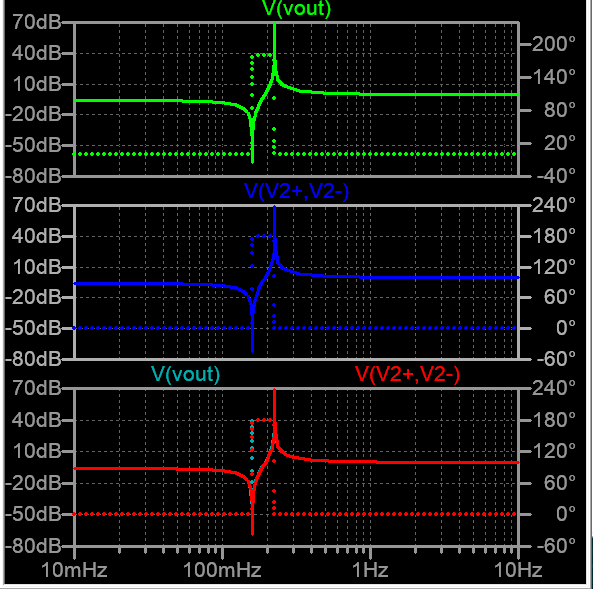

</div>

### Conclusiones/Comentarios

Luego de analizar el circuito con GICs como sub-circuitos de parámetros T interconectados en cascada, se puede concluir que:

1. La implementación de GICs permite una mayor flexibilidad en el diseño de circuitos, facilitando la interconexión de diferentes etapas.
2. Los resultados de la simulación muestran que el comportamiento del circuito con GICs es equivalente al de un circuito con Lattice, lo que valida la metodología utilizada.
3. La utilización de sub-circuitos en LTSpice simplifica el análisis y la modificación del circuito, permitiendo una mejor organización del diseño.

No obstante, a pesar de la versatilidad que ofrecen los GICs, un circuito lattice puede ser más eficiente en términos de espacio y recursos, dependiendo de la aplicación específica.
Ambos se comportan de igual manera. La elección entre uno u otro dependerá de los requisitos específicos del diseño y las restricciones del entorno de implementación.

Se comparó el gráfico de módulo y fase de la transferencia del parámetro $A$ de la matriz de parámetros T con las simulaciones obtenidas de ambos circuitos, confirmando su equivalencia.


## Referencias

- Apuntes y Bibliografía del curso
- [Clase 8: Cuadripolos lineales, parámetros Z e Y - Teoría de Circuitos 2 - UTN FRBA - Ingeniería Electrónica - YouTube](https://www.youtube.com/playlist?list=PLlD2eDv5CIe8DLWIFnct6DiKmmf8wdmx-)
- [Clase 9: Parámetros T o ABCD, inteconexión de cuadripolos - Teoría de Circuitos 2 - UTN FRBA - Ingeniería Electrónica - YouTube](https://www.youtube.com/playlist?list=PLlD2eDv5CIe9CKGculHz1xhaz4y7lIIxw)
- [Clase 10 - Cuadripolos cargados, conversores de imitancias. Teoría de Circuitos 2 - UTN FRBA - Ingeniería Electrónica - YouTube](https://www.youtube.com/playlist?list=PLlD2eDv5CIe-JeleIhz3WcJ9VlS-iehNu)
- [.NET -- Compute Network Parameters in a .AC Analysis](https://ltwiki.org/LTspiceHelp/LTspiceHelp/_NET_Compute_Network_Parameters_in_a_AC_Analysis.htm)
- [B sources (complete reference) - LTwiki-Wiki for LTspice](https://ltwiki.org/?title=B_sources_%28complete_reference%29)
- [LTspice: Behavioral Voltage Sources - YouTube](https://www.youtube.com/watch?v=JWm8z5fyhP8)
- [LTspice tutorial - Network parameters and the .net statement (part 2/2) - YouTube](https://www.youtube.com/watch?v=SJyVnGnwDXQ)